1. Import Python libs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Import file

In [2]:
from google.colab import files

uploaded = files.upload()

Saving hotel_bookings_clean.csv to hotel_bookings_clean.csv


3. Read .csv file


In [3]:
df = pd.read_csv("hotel_bookings_clean.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


4. Check the data

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Number of rows: 119390
Number of columns: 32
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          1

5. Calculate correlations

In [6]:
# Select numerical variables
numeric_data = df.select_dtypes(include="number")

# Calculate correlation matrix
correlation_matrix = numeric_data.corr()

# Display correlation matrix
correlation_matrix

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.000000,0.293123,0.016660,0.008148,-0.006130,-0.001791,0.024765,0.060017,0.005048,-0.032491,-0.084793,0.110133,-0.057358,-0.144381,-0.083114,-0.020642,0.054186,0.047557,-0.195498,-0.234658
lead_time,0.293123,1.000000,0.040142,0.126871,0.002268,0.085671,0.165799,0.119519,-0.037622,-0.020915,-0.124410,0.086042,-0.073548,0.000149,-0.069741,0.151464,0.170084,-0.063077,-0.116451,-0.095712
arrival_date_year,0.016660,0.040142,1.000000,-0.540561,-0.000221,0.021497,0.030883,0.029635,0.054624,-0.013192,0.010341,-0.119822,0.029218,0.030872,0.063457,0.259095,-0.056497,0.197580,-0.013684,0.108531
arrival_date_week_number,0.008148,0.126871,-0.540561,1.000000,0.066809,0.018208,0.015558,0.025909,0.005518,0.010395,-0.030131,0.035501,-0.020904,0.005508,-0.031201,-0.076760,0.022933,0.075791,0.001920,0.026149
arrival_date_day_of_month,-0.006130,0.002268,-0.000221,0.066809,1.000000,-0.016354,-0.028174,-0.001566,0.014544,-0.000230,-0.006145,-0.027011,-0.000300,0.010613,0.001487,0.044858,0.022728,0.030245,0.008683,0.003062
stays_in_weekend_nights,-0.001791,0.085671,0.021497,0.018208,-0.016354,1.000000,0.498969,0.091871,0.045793,0.018483,-0.087239,-0.012775,-0.042715,0.063281,0.140739,0.066749,-0.054151,0.049342,-0.018554,0.072671
stays_in_week_nights,0.024765,0.165799,0.030883,0.015558,-0.028174,0.498969,1.000000,0.092976,0.044203,0.020191,-0.097245,-0.013992,-0.048743,0.096209,0.182382,0.182211,-0.002020,0.065237,-0.024859,0.068192
adults,0.060017,0.119519,0.029635,0.025909,-0.001566,0.091871,0.092976,1.000000,0.030447,0.018146,-0.146426,-0.006738,-0.107983,-0.051673,-0.035594,0.207793,-0.008283,0.230641,0.014785,0.122884
children,0.005048,-0.037622,0.054624,0.005518,0.014544,0.045793,0.044203,0.030447,1.000000,0.024030,-0.032859,-0.024730,-0.021072,0.048949,0.041066,0.030931,-0.033273,0.324854,0.056253,0.081745
babies,-0.032491,-0.020915,-0.013192,0.010395,-0.000230,0.018483,0.020191,0.018146,0.024030,1.000000,-0.008943,-0.007501,-0.006550,0.083440,0.036184,0.019206,-0.010621,0.029186,0.037383,0.097889


6. Display the correlation matrix as a heatmap

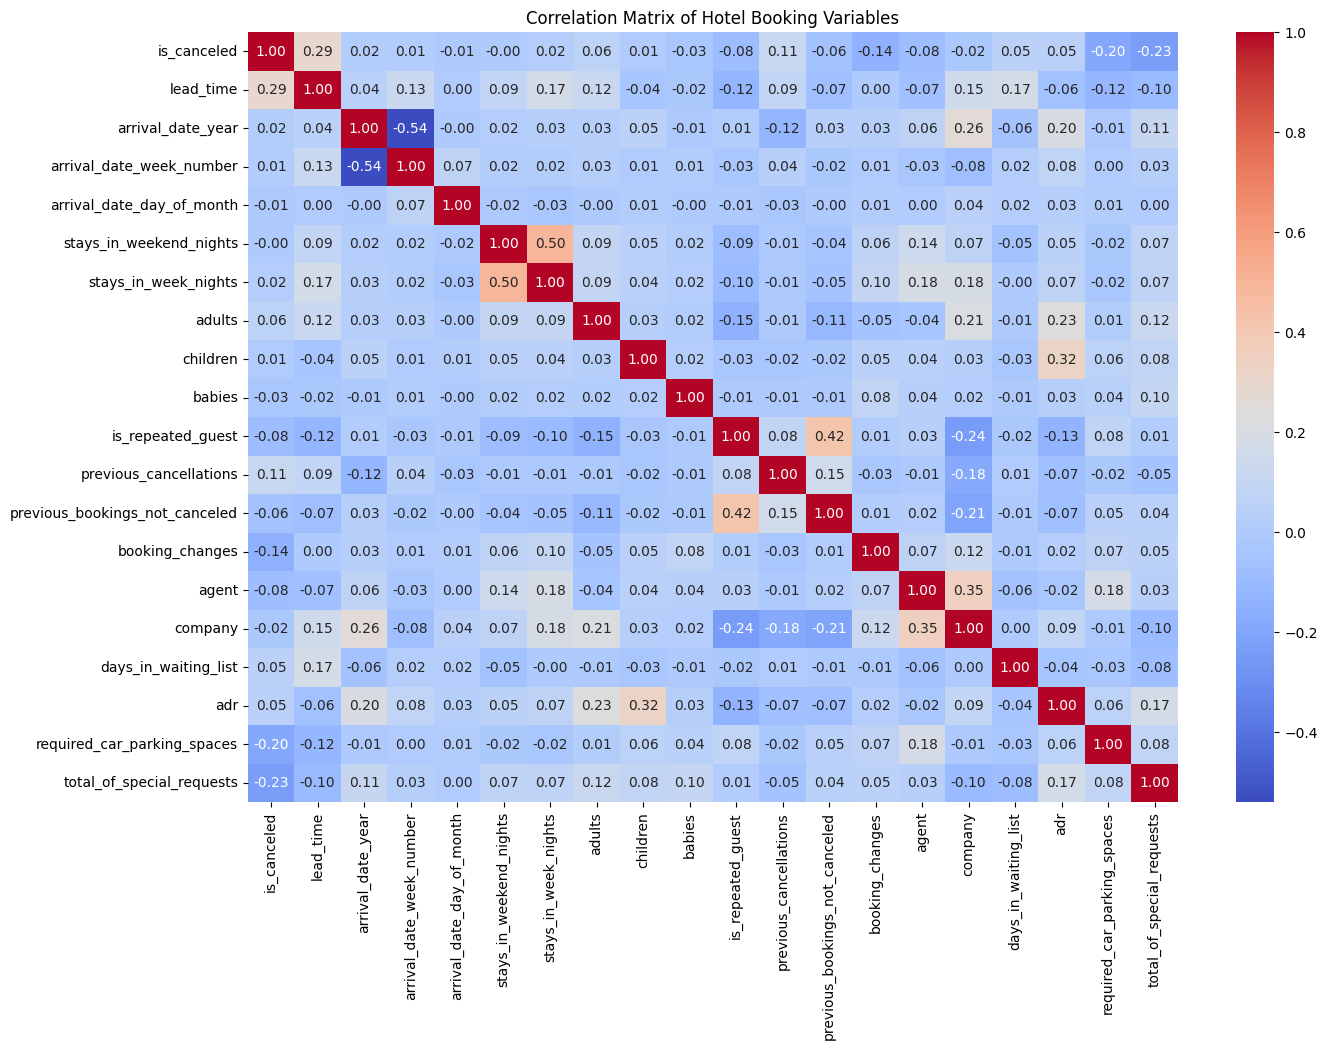

In [7]:
plt.figure(figsize=(15, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Hotel Booking Variables")
plt.show()

7. Find the strongest correlations

In [8]:
# Get correlations from the upper triangle only
corr = correlation_matrix.copy()

# Remove the diagonal and lower triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Convert to a table
strong_correlations = corr.where(mask).stack().reset_index()

# Rename columns
strong_correlations.columns = [
    "Variable 1",
    "Variable 2",
    "Correlation"
]

# Sort by absolute correlation
strong_correlations["Absolute Correlation"] = (
    strong_correlations["Correlation"].abs()
)

strong_correlations = strong_correlations.sort_values(
    "Absolute Correlation",
    ascending=False
)

# Show top 10
strong_correlations.head(10)

,Variable 1,Variable 2,Correlation,Absolute Correlation
37,arrival_date_year,arrival_date_week_number,-0.540561,0.540561
85,stays_in_weekend_nights,stays_in_week_nights,0.498969,0.498969
146,is_repeated_guest,previous_bookings_not_canceled,0.418056,0.418056
175,agent,company,0.350746,0.350746
132,children,adr,0.324854,0.324854
0,is_canceled,lead_time,0.293123,0.293123
49,arrival_date_year,company,0.259095,0.259095
149,is_repeated_guest,company,-0.244586,0.244586
18,is_canceled,total_of_special_requests,-0.234658,0.234658
121,adults,adr,0.230641,0.230641


8. Print the results


In [9]:
print("Top 10 strongest correlations:\n")

for _, row in strong_correlations.head(10).iterrows():
    print(
        f"{row['Variable 1']} <-> {row['Variable 2']}: "
        f"{row['Correlation']:.3f}"
    )

Top 10 strongest correlations:

arrival_date_year <-> arrival_date_week_number: -0.541
stays_in_weekend_nights <-> stays_in_week_nights: 0.499
is_repeated_guest <-> previous_bookings_not_canceled: 0.418
agent <-> company: 0.351
children <-> adr: 0.325
is_canceled <-> lead_time: 0.293
arrival_date_year <-> company: 0.259
is_repeated_guest <-> company: -0.245
is_canceled <-> total_of_special_requests: -0.235
adults <-> adr: 0.231


9. Example: Lead time and cancellation

In [10]:
correlation = df["lead_time"].corr(df["is_canceled"])

print(
    "Correlation between lead_time and is_canceled:",
    round(correlation, 3)
)

Correlation between lead_time and is_canceled: 0.293


10. Scatter plot

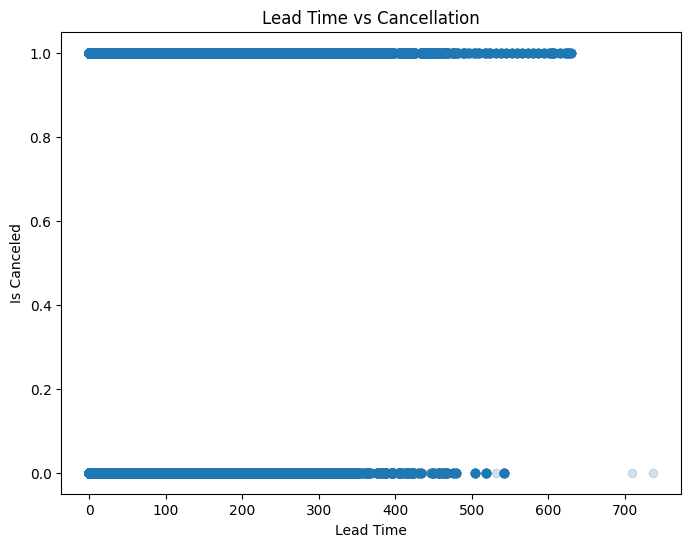

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["lead_time"],
    df["is_canceled"],
    alpha=0.2
)

plt.xlabel("Lead Time")
plt.ylabel("Is Canceled")
plt.title("Lead Time vs Cancellation")

plt.show()

11. Select variables

In [13]:
X = df[
    [
        "adults",
        "children",
        "lead_time",
        "stays_in_week_nights",
        "total_of_special_requests"
    ]
]

y = df["adr"]

# Remove rows containing missing values
data = pd.concat([X, y], axis=1).dropna()

X = data[
    [
        "adults",
        "children",
        "lead_time",
        "stays_in_week_nights",
        "total_of_special_requests"
    ]
]

y = data["adr"]

12. Create the regression model

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

13. Print results


In [15]:
y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)

print("\nCoefficients:")

for variable, coefficient in zip(X.columns, model.coef_):
    print(variable, ":", coefficient)

print("\nR²:", r2_score(y_test, y_pred))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, y_pred))
)

Intercept: 59.22428682195607

Coefficients:
adults : 19.312085330402535
children : 38.456203386617744
lead_time : -0.034391450913624055
stays_in_week_nights : 0.9250018617270315
total_of_special_requests : 7.037020694743399

R²: 0.18668913612532645
RMSE: 43.51982480300652


In [18]:
# =======================
# BINARY LOGISTIC REGRESSION
# =======================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    roc_curve
)

In [21]:
# Define X and y
X = df.drop(columns=["is_canceled"])
y = df["is_canceled"]

# Select numerical and categorical variables
numeric_features = [
    "lead_time",
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

categorical_features = [
    "hotel",
    "arrival_date_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "deposit_type",
    "customer_type"
]

# Keep only selected variables
X = X[numeric_features + categorical_features]

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Logistic regression pipeline
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Fit the model
logistic_model.fit(X_train, y_train)

print("Logistic regression model fitted successfully.")

Logistic regression model fitted successfully.


1. Estimate the coefficients

In [22]:

fitted_preprocessor = logistic_model.named_steps["preprocessor"]
classifier = logistic_model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = classifier.coef_[0]
intercept = classifier.intercept_[0]

coefficient_table = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
})

coefficient_table["Absolute_Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("Intercept:", round(intercept, 6))
print("\nEstimated coefficients:")
display(coefficient_table.drop(columns="Absolute_Coefficient"))

print("\nLargest coefficients by absolute magnitude:")
display(
    coefficient_table.head(15)[
        ["Variable", "Coefficient", "Odds_Ratio"]
    ]
)

Intercept: -0.602771

Estimated coefficients:


,Variable,Coefficient,Odds_Ratio
14,num__required_car_parking_spaces,-4.998269,0.006750
231,cat__deposit_type_Non Refund,2.859570,17.454012
40,cat__country_ARE,2.378334,10.786915
229,cat__reserved_room_type_P,1.961871,7.112621
129,cat__country_LTU,-1.942749,0.143310
...,...,...,...
18,cat__arrival_date_month_April,0.009075,1.009116
86,cat__country_ETH,0.008752,1.008790
3,num__arrival_date_day_of_month,0.007463,1.007491
221,cat__reserved_room_type_B,-0.005170,0.994843



Largest coefficients by absolute magnitude:


,Variable,Coefficient,Odds_Ratio
14,num__required_car_parking_spaces,-4.998269,0.006750
231,cat__deposit_type_Non Refund,2.859570,17.454012
40,cat__country_ARE,2.378334,10.786915
229,cat__reserved_room_type_P,1.961871,7.112621
129,cat__country_LTU,-1.942749,0.143310
9,num__previous_cancellations,1.914577,6.784069
230,cat__deposit_type_No Deposit,-1.865534,0.154814
101,cat__country_HKG,1.709783,5.527762
132,cat__country_MAC,1.677312,5.351154
151,cat__country_NGA,1.610740,5.006513


2. Derive the logistic regression equation

In [23]:
equation_terms = [f"({intercept:.6f})"]

for name, coef in zip(feature_names, coefficients):
    sign = "+" if coef >= 0 else "-"
    equation_terms.append(
        f"{sign} ({abs(coef):.6f} * {name})"
    )

equation = " ".join(equation_terms)

print("Logit equation:")
print("log(p / (1 - p)) =", equation)

print("\nProbability equation:")
print("P(cancellation = Yes) = 1 / (1 + exp(-z))")
print("where z is the linear expression above.")

Logit equation:
log(p / (1 - p)) = (-0.602771) + (0.619168 * num__lead_time) + (0.227666 * num__arrival_date_year) - (0.042045 * num__arrival_date_week_number) + (0.007463 * num__arrival_date_day_of_month) + (0.111370 * num__stays_in_weekend_nights) + (0.160986 * num__stays_in_week_nights) + (0.103277 * num__adults) + (0.067441 * num__children) + (0.009393 * num__babies) + (1.914577 * num__previous_cancellations) - (0.865898 * num__previous_bookings_not_canceled) - (0.254078 * num__booking_changes) - (0.043383 * num__days_in_waiting_list) + (0.298825 * num__adr) - (4.998269 * num__required_car_parking_spaces) - (0.624269 * num__total_of_special_requests) - (0.093326 * cat__hotel_City Hotel) - (0.293127 * cat__hotel_Resort Hotel) + (0.009075 * cat__arrival_date_month_April) - (0.188643 * cat__arrival_date_month_August) + (0.332025 * cat__arrival_date_month_December) - (0.015803 * cat__arrival_date_month_February) - (0.269198 * cat__arrival_date_month_January) - (0.334696 * cat__arrival_

3. Create a confusion matrix

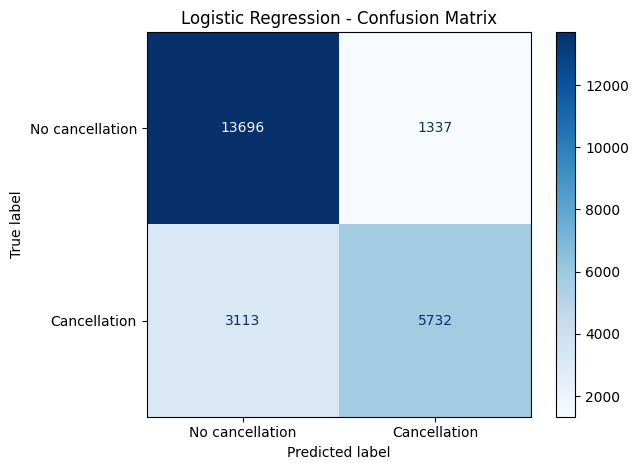

Confusion matrix:
[[13696  1337]
 [ 3113  5732]]


In [24]:
y_pred = logistic_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No cancellation", "Cancellation"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

print("Confusion matrix:")
print(cm)

4. Calculate classification metrics

In [25]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

metrics_table["Value"] = metrics_table["Value"].round(4)

display(metrics_table)

print("\nDetailed classification report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["No cancellation", "Cancellation"],
    zero_division=0
))

,Metric,Value
0,Accuracy,0.8136
1,Precision,0.8109
2,Recall,0.6480
3,F1-score,0.7204
4,ROC-AUC,0.8889



Detailed classification report:
                 precision    recall  f1-score   support

No cancellation       0.81      0.91      0.86     15033
   Cancellation       0.81      0.65      0.72      8845

       accuracy                           0.81     23878
      macro avg       0.81      0.78      0.79     23878
   weighted avg       0.81      0.81      0.81     23878



5. Generate probability predictions for "No" or "Yes"

In [26]:
probabilities = logistic_model.predict_proba(X_test)

predictions_df = X_test.copy()

predictions_df["Actual"] = y_test.map({
    0: "No",
    1: "Yes"
})

predictions_df["Probability_No"] = probabilities[:, 0]
predictions_df["Probability_Yes"] = probabilities[:, 1]

predictions_df["Predicted_Class"] = np.where(
    probabilities[:, 1] >= 0.5,
    "Yes",
    "No"
)

print("Example probability predictions:")
display(predictions_df.head(10).round(4))

# Demonstrate a prediction for a new observation.
new_observation = X_test.iloc[[0]].copy()

new_probabilities = logistic_model.predict_proba(new_observation)[0]
new_prediction = logistic_model.predict(new_observation)[0]

print("\nExample new observation:")
display(new_observation)

print(f"Probability of No cancellation: {new_probabilities[0]:.4f}")
print(f"Probability of Yes cancellation: {new_probabilities[1]:.4f}")
print(
    "Predicted outcome:",
    "Yes" if new_prediction == 1 else "No"
)

Example probability predictions:


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,...,country,market_segment,distribution_channel,reserved_room_type,deposit_type,customer_type,Actual,Probability_No,Probability_Yes,Predicted_Class
93581,14,2016,30,21,0,2,2,0.0,0,0,...,PRT,Corporate,Corporate,A,No Deposit,Transient-Party,No,0.8629,0.1371,No
115055,6,2017,26,30,0,1,2,0.0,0,0,...,SWE,Online TA,TA/TO,A,No Deposit,Transient-Party,No,0.8645,0.1355,No
56243,120,2016,36,1,1,3,2,0.0,0,0,...,CN,Online TA,TA/TO,A,No Deposit,Transient,Yes,0.4836,0.5164,Yes
38448,0,2017,29,18,0,0,2,0.0,0,0,...,PRT,Direct,Direct,A,No Deposit,Transient,No,0.8371,0.1629,No
87074,138,2016,16,13,0,1,2,0.0,0,0,...,PRT,Groups,TA/TO,A,No Deposit,Transient-Party,No,0.7570,0.2430,No
10667,103,2017,13,27,1,1,2,0.0,0,0,...,PRT,Groups,Corporate,E,Non Refund,Transient,Yes,0.0047,0.9953,Yes
70390,226,2017,24,16,1,2,2,0.0,0,0,...,PRT,Offline TA/TO,TA/TO,A,Non Refund,Transient,Yes,0.0037,0.9963,Yes
48445,82,2016,13,23,0,4,2,2.0,0,0,...,ESP,Online TA,TA/TO,F,No Deposit,Transient,No,0.3890,0.6110,Yes
17870,7,2015,43,24,0,1,1,0.0,0,0,...,PRT,Online TA,TA/TO,A,No Deposit,Transient,No,0.8062,0.1938,No
46793,151,2016,4,19,0,3,1,0.0,0,0,...,DEU,Offline TA/TO,TA/TO,A,No Deposit,Transient-Party,No,0.9782,0.0218,No



Example new observation:


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,...,total_of_special_requests,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,deposit_type,customer_type
93581,14,2016,30,21,0,2,2,0.0,0,0,...,0,City Hotel,July,BB,PRT,Corporate,Corporate,A,No Deposit,Transient-Party


Probability of No cancellation: 0.8629
Probability of Yes cancellation: 0.1371
Predicted outcome: No
